## Notebook 04: MLP vs CNN — Robustness to Translation

This notebook loads the trained MLP (from notebook 02) and CNN (from notebook 03) and
evaluates both on test images shifted by a fixed number of pixels (0, 1, 2, 4, 6, 8),
applied identically in both the x and y direction. Unlike random data augmentation, each
shift amount here is exact and deterministic, allowing a precise, controlled comparison
of how quickly each architecture's accuracy degrades as spatial alignment between
training and test data breaks down.

# 04 - MLP vs CNN Robustness

This notebook evaluates how both architectures behave when the input images are slightly translated.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/cifar10-mlp-vs-cnn/notebooks')

os.makedirs('../results/figures', exist_ok=True)

metrics_path = '../results/metrics.json'

In [3]:
from pathlib import Path
import sys
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / 'src'))

from data import get_dataloaders, apply_shift
from models import MLP, CNN
from train import evaluate

_, _, testloader, _, _, _ = get_dataloaders()

mlp_model = MLP(hidden_sizes=[1024, 512, 256], dropout=0.3)
mlp_model.load_state_dict(torch.load('../results/mlp_model.pt', map_location='cpu'))
mlp_model.eval()

cnn_model = CNN(use_pooling=True)
cnn_model.load_state_dict(torch.load('../results/cnn_model.pt', map_location='cpu'))
cnn_model.eval()

def evaluate_with_shift(model, loader, shift_x, shift_y, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            shifted = torch.stack([apply_shift(img, shift_x, shift_y) for img in inputs])
            shifted, targets = shifted.to(device), targets.to(device)
            outputs = model(shifted)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return 100. * correct / total

shifts = [0, 1, 2, 4, 6, 8]
mlp_results, cnn_results = [], []
for s in shifts:
    mlp_acc = evaluate_with_shift(mlp_model, testloader, s, s)
    cnn_acc = evaluate_with_shift(cnn_model, testloader, s, s)
    mlp_results.append(mlp_acc)
    cnn_results.append(cnn_acc)
    print(f"Shift = {s}px | MLP: {mlp_acc:.2f}% | CNN: {cnn_acc:.2f}%")



Shift = 0px | MLP: 57.40% | CNN: 82.01%
Shift = 1px | MLP: 53.14% | CNN: 80.46%
Shift = 2px | MLP: 46.72% | CNN: 76.49%
Shift = 4px | MLP: 32.37% | CNN: 61.86%
Shift = 6px | MLP: 21.75% | CNN: 47.25%
Shift = 8px | MLP: 16.81% | CNN: 32.46%


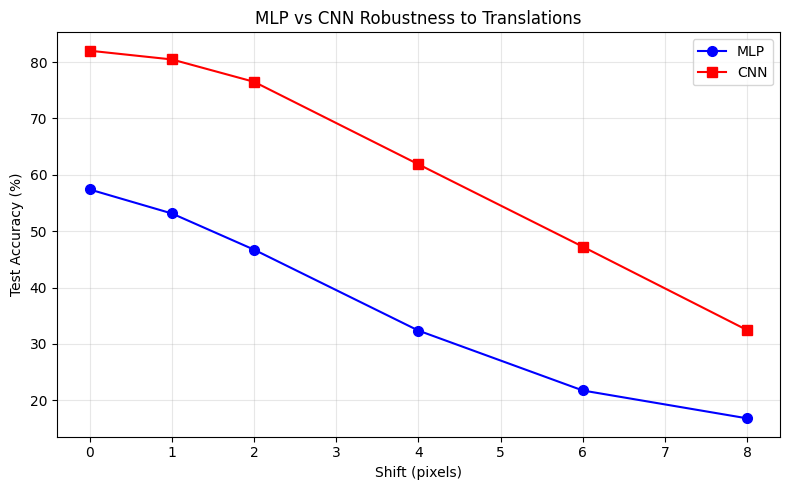

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(shifts, mlp_results, 'b-o', label='MLP', markersize=7)
plt.plot(shifts, cnn_results, 'r-s', label='CNN', markersize=7)
plt.xlabel('Shift (pixels)')
plt.ylabel('Test Accuracy (%)')
plt.title('MLP vs CNN Robustness to Translations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/robustness_translations.png', dpi=200, bbox_inches='tight')
plt.show()

### Robustness to Input Translations

| Shift | MLP Accuracy | CNN Accuracy |
|---|---|---|
| 0px | 57.40% | 82.01% |
| 1px | 53.14% | 80.46% |
| 2px | 46.72% | 76.49% |
| 4px | 32.37% | 61.86% |
| 6px | 21.75% | 47.25% |
| 8px | 16.81% | 32.46% |

**CNN Resilience**: The CNN remains relatively stable for small translations (0–2px),
dropping only from 82.01% to 76.49% — a ~5.5-point decline. This is due to pooling
layers and convolutional kernels, which provide local translation invariance: a
convolutional filter that detects a feature in one location will still respond to that
same feature if it shifts by a pixel or two, since the filter is applied identically
across every spatial position.

**MLP Sensitivity**: The MLP degrades much faster, even at a 1-pixel shift (57.40% →
53.14%, a ~4.3-point drop) and continues falling steeply (46.72% by 2px). Because the
MLP maps each of its 3072 fixed input positions to specific learned weights, it expects
a given feature (an eye, a wheel, a patch of sky) to appear at the exact same pixel
coordinates every time. A shift misaligns every pixel with the weights trained for that
position, so even small translations destroy the input-to-weight correspondence the
model relies on.

**Content Loss at Scale**: At larger shifts (6–8px), both models degrade sharply
(CNN: 47.25% → 32.46%; MLP: 21.75% → 16.81%), approaching or nearing the 10%
random-guess baseline for 10 classes. At this point the comparison is no longer purely
about architectural robustness — large shifts push the original subject partly out of
frame, discarding real visual information that no architecture, however robust, can
recover from. The gap between CNN and MLP narrows somewhat at these extreme shifts
because both are now fundamentally information-limited rather than architecture-limited.

**Conclusion**: Across every shift level, the CNN consistently outperforms the MLP by a
wide margin, and — more importantly for this experiment — degrades *more slowly* as
translation increases. This is direct empirical evidence that convolutional architectures
possess a meaningful degree of built-in translation robustness that fully-connected
architectures lack entirely, consistent with the architectural differences discussed in
notebooks 02 and 03 (spatial invariance to pixel shuffling, weight sharing, and local
connectivity).